In [1]:
%pip install -U scikit-learn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 13.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
import optuna
from sklearn.preprocessing import LabelEncoder


 Dataset shape: (7668, 87)
 Dropped 68 columns: pl_trandurhlim, pl_trandeperr2, pl_eqtsymerr, pl_tranmiderr1, st_tefflim...
 New Dataset shape after feature selection: (7668, 19)
 Numeric features: 18
 Categorical features: 0
 Class distribution after SMOTE: [4675 4675 4675 4675 4675 4675]
✅ Cross-validation for accuracy finished.
Accuracy Scores: [0.94741533 0.9483066  0.95080214 0.95062389 0.94901961]
Mean accuracy: 0.9492335115864527

✅ Cross-validation for F1 Score finished.
F1 Scores (Weighted): [0.94654714 0.94696131 0.94994422 0.94979899 0.9482058 ]
Mean F1 Score (Weighted): 0.9482914922734331

✅ Generating Confusion Matrix...
Confusion matrix plot saved as confusion_matrix.png


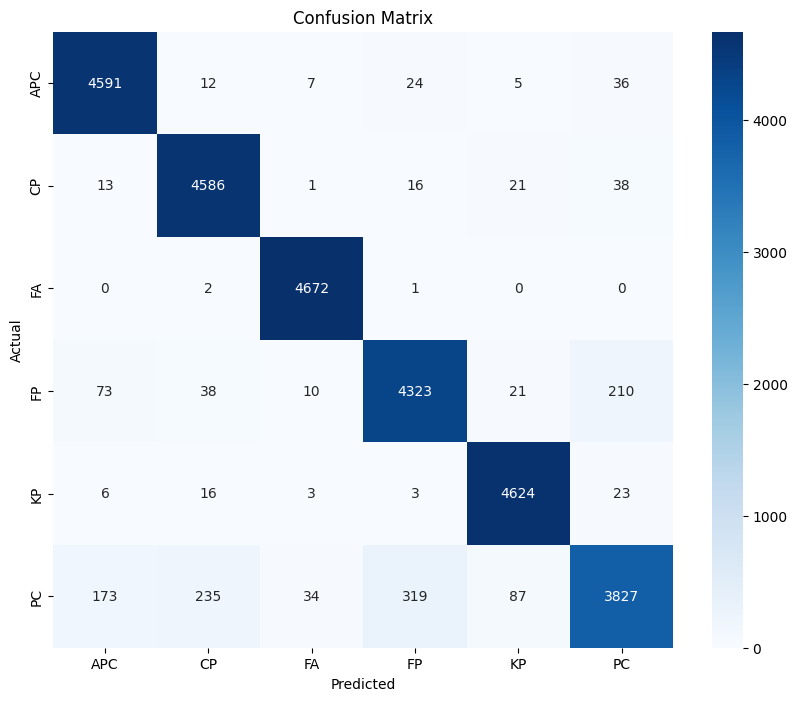

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Load dataset ---
# Assuming the file path is correct in your environment
df = pd.read_csv("/kaggle/input/t2nasa/TOI_2025.09.22_23.36.58.csv", comment="#")
print(" Dataset shape:", df.shape)

# --- Drop useless / highly-null cols (Original logic retained) ---
l = [col for col in df.columns if df[col].isnull().sum() >= 5660]
target = "tfopwg_disp"
if target not in df.columns:
    raise ValueError(f"Target column {target} missing!")

# 1. FEATURE REDUCTION (NEW LOGIC): Drop all error, limit, and string/identifier columns.
cols_to_drop_init = ['rowid', 'tid', 'ctoi_alias', 'toipfx', 'toi_created', 'rowupdate'] + l

# Identify all error/limit columns by common suffixes
error_suffixes = ['err1', 'err2', 'lim', 'symerr', 'str'] # 'str' covers rastr and decstr
cols_to_drop_error = [
    col for col in df.columns
    if any(col.endswith(suffix) for suffix in error_suffixes)
]

# Combine and ensure no duplicates or target column are dropped
all_cols_to_drop = list(set(cols_to_drop_init + cols_to_drop_error))
if target in all_cols_to_drop:
    all_cols_to_drop.remove(target) # Safety check

df.drop(columns=all_cols_to_drop, inplace=True, errors='ignore')

print(f" Dropped {len(all_cols_to_drop)} columns: {', '.join(all_cols_to_drop[:5])}...")
print(" New Dataset shape after feature selection:", df.shape)

# --- Split X and y ---
X = df.drop(columns=[target])
y = df[target]

# --- Feature separation ---
num_features = X.select_dtypes(include=[np.number]).columns
cat_features = X.select_dtypes(exclude=[np.number]).columns
print(" Numeric features:", len(num_features))
print(" Categorical features:", len(cat_features))

# --- Numeric preprocessing (Retain original logic: Median Imputer + StandardScaler) ---
if len(num_features) > 0:
    imputer_num = SimpleImputer(strategy="median")
    X[num_features] = imputer_num.fit_transform(X[num_features])

    scaler = StandardScaler()
    X[num_features] = scaler.fit_transform(X[num_features])

# --- Categorical preprocessing (Retain original logic: M.F. Imputer + OHE) ---
if len(cat_features) > 0:
    imputer_cat = SimpleImputer(strategy="most_frequent")
    X[cat_features] = imputer_cat.fit_transform(X[cat_features])

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_cat_encoded = encoder.fit_transform(X[cat_features])
    X_cat_encoded = pd.DataFrame(X_cat_encoded,
                                 columns=encoder.get_feature_names_out(cat_features),
                                 index=X.index)

    X = pd.concat([X.drop(columns=cat_features), X_cat_encoded], axis=1)

# --- Encode target ---
le = LabelEncoder()
y = le.fit_transform(y)
# Store the class names for later plotting
class_names = le.classes_

# --- Apply SMOTE ---
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print(" Class distribution after SMOTE:", np.bincount(y_res))

# --- Model with HYPERPARAMETER TUNING (MODIFIED) ---
params = {"objective": "multiclass",
          "num_class": len(set(y_res)),
          "metric": "multi_logloss",
          "verbosity": -1,
          "boosting_type": "gbdt",'n_estimators': 1715, 'learning_rate': 0.03190642369104035, 'num_leaves': 83, 'max_depth': 10, 'min_child_samples': 16, 'colsample_bytree': 0.926152633101521, 'subsample': 0.8164210948966338, 'subsample_freq': 1}
model = LGBMClassifier(
    **params, random_state=42
)

# --- Cross-validation (MODIFIED - Using cross_val_score for cleanliness) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Accuracy Calculation (from your original code) ---
accuracy_scores = cross_val_score(model, X_res, y_res, cv=cv, scoring='accuracy')
print("✅ Cross-validation for accuracy finished.")
print("Accuracy Scores:", accuracy_scores)
print("Mean accuracy:", np.mean(accuracy_scores))


# --- F1 Score Calculation (NEW) ---
# We use 'f1_weighted' which is suitable for multiclass problems, especially with imbalance.
f1_scores = cross_val_score(model, X_res, y_res, cv=cv, scoring='f1_weighted')
print("\n✅ Cross-validation for F1 Score finished.")
print("F1 Scores (Weighted):", f1_scores)
print("Mean F1 Score (Weighted):", np.mean(f1_scores))

# --- Confusion Matrix Calculation & Plotting (NEW) ---
# Get cross-validated predictions
y_pred = cross_val_predict(model, X_res, y_res, cv=cv)

print("\n✅ Generating Confusion Matrix...")
# Compute confusion matrix
cm = confusion_matrix(y_res, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
print("Confusion matrix plot saved as confusion_matrix.png")

In [4]:
"""
import optuna
import lightgbm as lgb
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, make_scorer
# Assuming X_res (SMOTE'd features) and y_res (SMOTE'd labels) are available in the scope
# from the previous processing steps.
warnings.filterwarnings("ignore")

def objective(trial):
    
    # 1. Update parameter ranges based on analysis and best practices
    param = {
        "objective": "multiclass",
        # Use y_res to correctly set the number of classes after SMOTE (though it should be the same as y)
        "num_class": len(set(y_res)), 
        "metric": "multi_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000), # Increased range
        # Targeted learning rate for better convergence
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        # num_leaves often best between 20-100 for tabular data
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        # max_depth often safe around 4-10
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        # min_child_samples is the equivalent of min_data_in_leaf
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50), 
        # feature_fraction (colsample_bytree in scikit-learn wrapper)
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.95), 
        # subsample (bagging_fraction in scikit-learn wrapper)
        "subsample": trial.suggest_float("subsample", 0.7, 0.95),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
    }

    # 2. Use the correct data: X_res and y_res
    model = lgb.LGBMClassifier(**param, random_state=42)
    # StratifiedKFold is essential, even on SMOTE'd data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
    
    # Use X_res and y_res
    scores = cross_val_score(
        model, 
        X_res, 
        y_res, 
        cv=cv, 
        scoring=make_scorer(accuracy_score)
    )
    
    return scores.mean()



# Execute the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100) # Increased n_trials for better exploration
print(" Best parameters:", study.best_params)
print(" Best accuracy:", study.best_value)
"""

'\nimport optuna\nimport lightgbm as lgb\nimport warnings\nfrom sklearn.model_selection import StratifiedKFold, cross_val_score\nfrom sklearn.metrics import accuracy_score, make_scorer\n# Assuming X_res (SMOTE\'d features) and y_res (SMOTE\'d labels) are available in the scope\n# from the previous processing steps.\nwarnings.filterwarnings("ignore")\n\ndef objective(trial):\n    \n    # 1. Update parameter ranges based on analysis and best practices\n    param = {\n        "objective": "multiclass",\n        # Use y_res to correctly set the number of classes after SMOTE (though it should be the same as y)\n        "num_class": len(set(y_res)), \n        "metric": "multi_logloss",\n        "verbosity": -1,\n        "boosting_type": "gbdt",\n        "n_estimators": trial.suggest_int("n_estimators", 500, 2000), # Increased range\n        # Targeted learning rate for better convergence\n        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),\n        # num_leave